# 04 - EDA: Sentiment & Category Analysis
## ShopEase Europe | Sentiment Analysis Project 
**Objective:** Explore sentiment patterns across product categories 
to identify which categories drive satisfaction and dissatisfaction. 
Findings will inform business recommendations and dashboard design.

In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import warnings
warnings.filterwarnings('ignore')



In [3]:
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
PROCESSED_DATA_PATH = os.path.join(PROJECT_ROOT, 'data', 'processed', 'clean_reviews.csv')
FIGURES_PATH = os.path.join(PROJECT_ROOT, 'reports', 'figures')

df = pd.read_csv(PROCESSED_DATA_PATH)

print(f"Dataset loaded: {df.shape[0]:,} rows x {df.shape[1]} columns")
print(f"Categories: {sorted(df['product_category'].unique())}")
print(f"Sentiments: {sorted(df['sentiment'].unique())}")

Dataset loaded: 120,000 rows x 14 columns
Categories: ['Beauty', 'Books', 'Electronics', 'Fashion', 'Food & Grocery', 'Home & Living', 'Sports', 'Toys']
Sentiments: ['negative', 'neutral', 'positive']


## 1.0 Sentiment Distribution by Product Category
Which product categories are driving positive and negative sentiment? 
This analysis identifies where ShopEase Europe is performing well 
and where customer experience needs attention.

In [4]:
# Sentiment counts per category
category_sentiment = df.groupby(['product_category', 'sentiment']).size().unstack(fill_value=0)
category_sentiment_pct = category_sentiment.div(category_sentiment.sum(axis=1), axis=0) * 100
category_sentiment_pct = category_sentiment_pct.round(2)

print("SENTIMENT DISTRIBUTION BY CATEGORY (%)")
print(category_sentiment_pct.to_string())

SENTIMENT DISTRIBUTION BY CATEGORY (%)
sentiment         negative  neutral  positive
product_category                             
Beauty               16.30    15.79     67.91
Books                16.09    15.42     68.49
Electronics          16.08    16.24     67.67
Fashion              15.63    16.68     67.68
Food & Grocery       15.92    15.75     68.33
Home & Living        16.25    15.95     67.80
Sports               15.78    16.08     68.14
Toys                 16.15    15.93     67.92


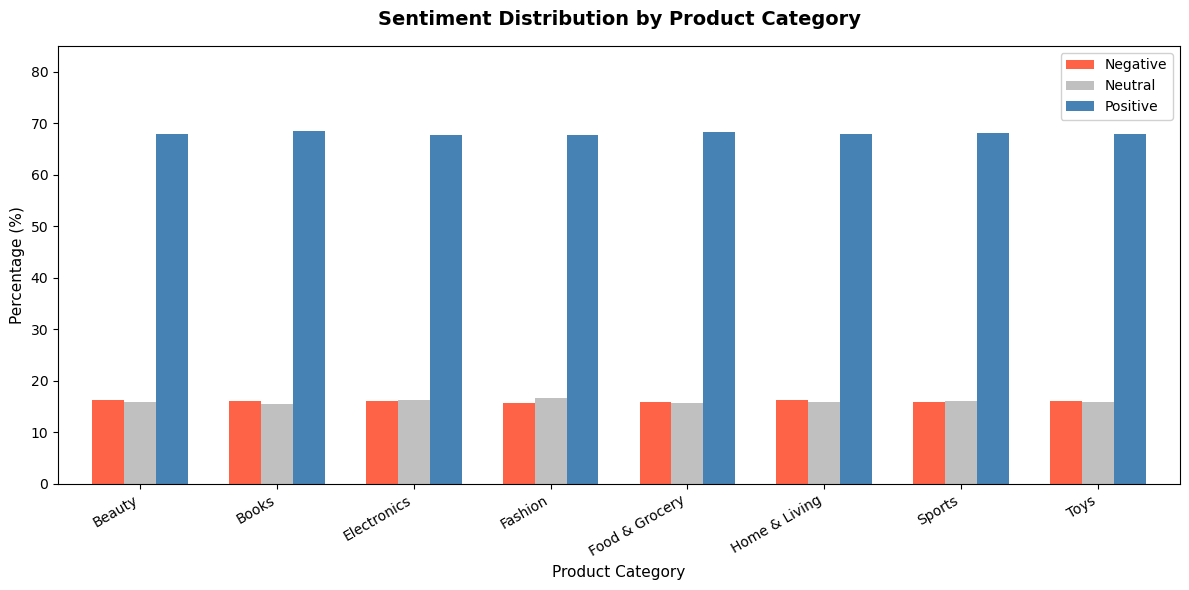

In [5]:
fig, ax = plt.subplots(figsize=(12, 6))

category_sentiment_pct.plot(
    kind='bar',
    ax=ax,
    color=['tomato', 'silver', 'steelblue'],
    width=0.7,
    edgecolor='none'
)

ax.set_title('Sentiment Distribution by Product Category', 
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Product Category', fontsize=11)
ax.set_ylabel('Percentage (%)', fontsize=11)
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')
ax.legend(['Negative', 'Neutral', 'Positive'], 
          loc='upper right', framealpha=0.9)
ax.set_ylim(0, 85)
ax.grid(False)

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_PATH, 'sentiment_by_category.png'), 
            dpi=150, bbox_inches='tight')
plt.show()

#### Insight


Sentiment is consistently positive across all eight product categories, 
with positive reviews averaging 68% regardless of category. Beauty and 
Books lead slightly in positive sentiment at 67.91% and 68.49% 
respectively, while Fashion records the lowest negative sentiment at 
15.63%, suggesting customers are generally satisfied with product 
presentation and variety in that category.



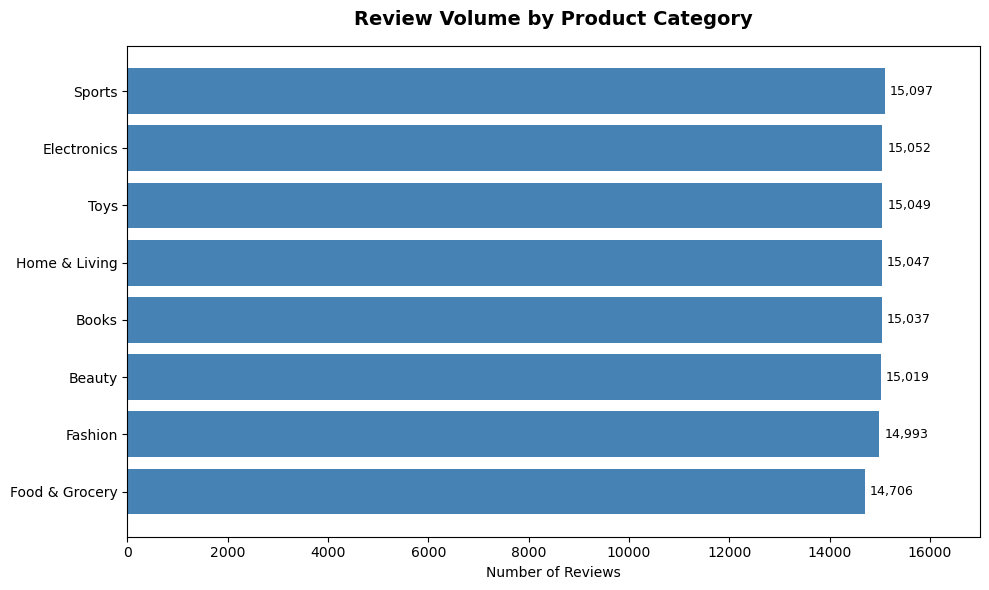

In [7]:
# Review volume per category
# Review volume per category
category_counts = df['product_category'].value_counts().sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(category_counts.index, category_counts.values, color='steelblue')

ax.set_title('Review Volume by Product Category', 
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Number of Reviews')
ax.set_xlim(0, 17000)
ax.grid(False)

for bar, count in zip(bars, category_counts.values):
    ax.text(bar.get_width() + 100, bar.get_y() + bar.get_height()/2,
            f'{count:,}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_PATH, 'review_volume_by_category.png'),
            dpi=150, bbox_inches='tight')
plt.show()

#### Insight
Sports generates the highest review volume at 15,097 reviews, followed 
closely by Electronics at 15,052 and Toys at 15,049. Food & Grocery 
records the lowest volume at 14,706, still a substantial number 
indicating strong customer engagement across the entire product range. 
The relatively balanced distribution suggests ShopEase Europe has 
achieved consistent customer engagement across all eight categories 
rather than being dominated by any single product line.


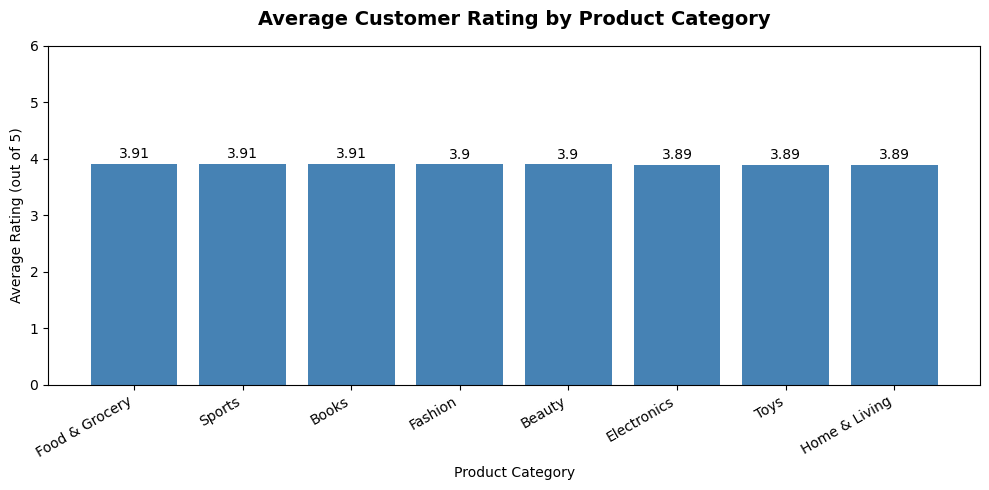

In [10]:
# Average rating per category
avg_rating = df.groupby('product_category')['rating'].mean().sort_values(ascending=False).round(2)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(avg_rating.index, avg_rating.values, color='steelblue')

ax.set_title('Average Customer Rating by Product Category',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Product Category')
ax.set_ylabel('Average Rating (out of 5)')
ax.set_ylim(0, 6)
ax.set_xticklabels(avg_rating.index, rotation=30, ha='right')
ax.grid(False)

for bar, rating in zip(bars, avg_rating.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            str(rating), ha='center', fontsize=10)

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_PATH, 'avg_rating_by_category.png'),
            dpi=150, bbox_inches='tight')
plt.show()

#### Insight
Average ratings are strong and consistent across all categories, 
ranging from 3.89 to 3.91 out of 5. Food & Grocery and Sports lead 
with 3.91, while Electronics, Toys and Home & Living sit at 3.89 
still well above the midpoint, indicating broad customer satisfaction 
across the product range.

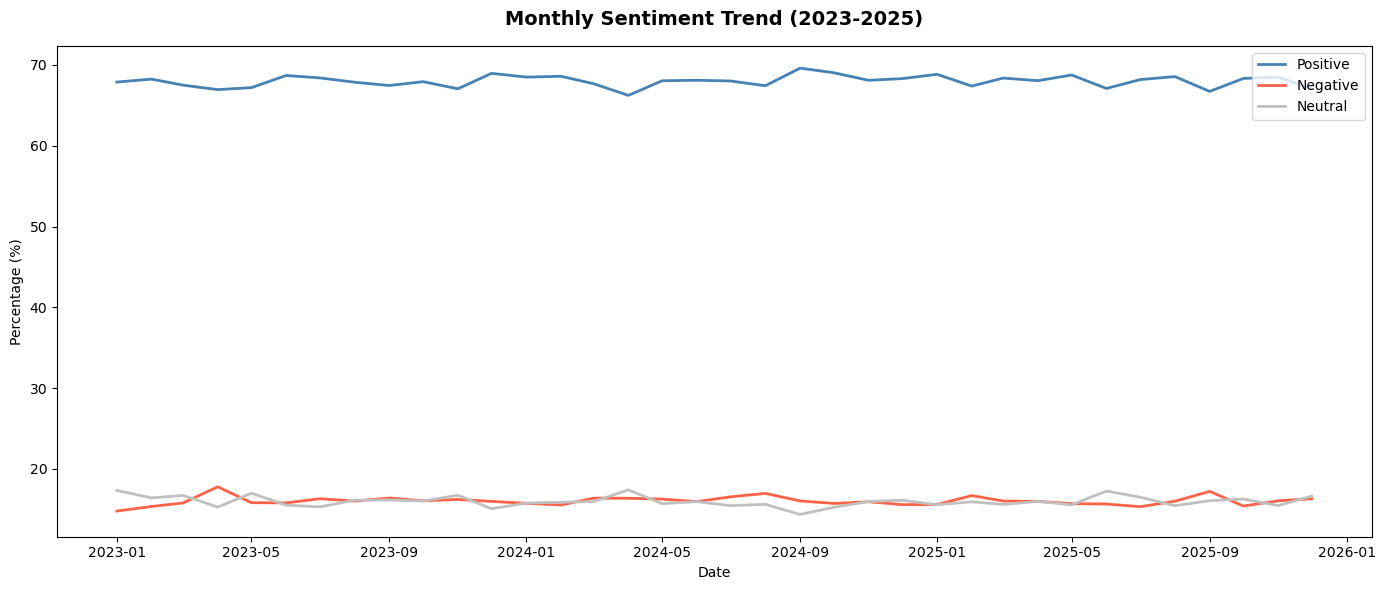

In [11]:
# Monthly sentiment trend
monthly_sentiment = df.groupby(['year', 'month', 'sentiment']).size().unstack(fill_value=0)
monthly_sentiment_pct = monthly_sentiment.div(monthly_sentiment.sum(axis=1), axis=0) * 100

# Create a proper date column for plotting
monthly_sentiment_pct = monthly_sentiment_pct.reset_index()
monthly_sentiment_pct['date'] = pd.to_datetime(
    monthly_sentiment_pct['year'].astype(str) + '-' + 
    monthly_sentiment_pct['month'].astype(str)
)
monthly_sentiment_pct = monthly_sentiment_pct.sort_values('date')

fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(monthly_sentiment_pct['date'], 
        monthly_sentiment_pct['positive'], 
        color='steelblue', linewidth=2, label='Positive')
ax.plot(monthly_sentiment_pct['date'], 
        monthly_sentiment_pct['negative'], 
        color='tomato', linewidth=2, label='Negative')
ax.plot(monthly_sentiment_pct['date'], 
        monthly_sentiment_pct['neutral'], 
        color='silver', linewidth=2, label='Neutral')

ax.set_title('Monthly Sentiment Trend (2023-2025)', 
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Date')
ax.set_ylabel('Percentage (%)')
ax.legend(loc='upper right')
ax.grid(False)

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_PATH, 'sentiment_trend_over_time.png'),
            dpi=150, bbox_inches='tight')
plt.show()

#### Insight

Positive sentiment has remained consistently dominant throughout 
2023-2025, showing no meaningful upward or downward trend over the 
three-year period. Minor month-to-month fluctuations are visible 
but fall within normal statistical variation rather than signalling 
any systematic change in customer experience.

Negative and neutral sentiment have similarly remained stable, 
suggesting ShopEase Europe has maintained a consistent customer 
experience over time. For the operations team, the absence of 
sentiment deterioration is a positive signal, however the lack 
of improvement trend also suggests no single initiative has 
dramatically elevated customer satisfaction during this period.